In [1]:
# تعریف ارتباطات بین نودها
connections = [
    (0, 1, 'r', 'c'), (1, 2, 'b', 't'), (1, 4, 'b', 'c'), (1, 5, 'r', 't'),
    (2, 3, 'g', 't'), (2, 6, 'r', 'c'), (3, 6, 'b', 'b'), (3, 8, 'g', 'b'),
    (3, 9, 'r', 't'), (4, 5, 'g', 'h'), (4, 10, 'g', 'b'), (4, 14, 'r', 'c'),
    (5, 6, 'g', 'h'), (5, 10, 'r', 'h'), (6, 7, 'r', 'c'), (6, 10, 'b', 'b'),
    (6, 11, 'g', 't'), (7, 8, 'r', 'h'), (7, 11, 'r', 'b'), (8, 9, 'b', 'h'),
    (8, 12, 'g', 't'), (8, 13, 'g', 'h'), (9, 13, 'r', 'b'), (10, 14, 'b', 't'),
    (10, 15, 'r', 'c'), (11, 12, 'b', 'b'), (11, 16, 'g', 't'), (11, 17, 'r', 'h'),
    (12, 13, 'b', 'h'), (12, 18, 'r', 't'), (13, 19, 'r', 'b'), (14, 20, 'r', 'b'),
    (14, 21, 'b', 'h'), (15, 16, 'g', 'c'), (15, 21, 'g', 'h'), (16, 17, 'b', 'c'),
    (16, 22, 'r', 't'), (17, 18, 'b', 'h'), (17, 23, 'r', 't'), (18, 19, 'b', 'b'),
    (18, 23, 'g', 'b'), (18, 24, 'g', 'c'), (18, 29, 'r', 'h'), (19, 24, 'g', 't'),
    (20, 21, 'g', 'b'), (20, 25, 'b', 'b'), (21, 22, 'r', 'c'), (21, 25, 'r', 'c'),
    (21, 26, 'g', 'b'), (21, 27, 'b', 't'), (22, 23, 'g', 'c'), (22, 27, 'r', 't'),
    (23, 28, 'r', 'h'), (24, 30, 'g', 't'), (25, 31, 'b', 'h'), (25, 26, 'r', 't'),
    (26, 27, 'r', 'c'), (26, 31, 'g', 'h'), (27, 28, 'g', 't'), (27, 32, 'r', 't'),
    (27, 33, 'b', 'b'), (28, 29, 'g', 'b'), (28, 33, 'r', 'c'), (29, 30, 'g', 'h'),
    (29, 34, 'r', 'h'), (30, 34, 'r', 'b'), (31, 32, 'b', 'c'), (32, 33, 'g', 'c'),
    (33, 34, 'r', 'b'), (34, 35, 'b', 'b')
]

In [2]:
# تعریف کلاس Road
class Road:
    def __init__(self, company='.', road_type='.'):
        self.company = company
        self.type = road_type

class Node:
    def __init__(self, village, age, parent=None):
        self.parent = parent
        self.children = []
        self.village = village
        self.age = age + 1
        self.done = False

    def add_children(self):
        """اضافه کردن فرزندان گره فعلی به گراف بر اساس داده‌های جاده‌ها"""
        self.done = True
        for i in range(36):
            if grid[self.village][i].type != '.' and grid[self.village][i].company != '.':
                if unexplored[self.village][i] > 0:
                    child = Node(i, self.age, self)
                    self.children.append(child)
                    unexplored[self.village][i] -= 1

        # افزودن فرزندان به صورت بازگشتی
        for child in self.children:
            if not child.done:
                child.add_children()

    def find_path_to(self, target, path=None):
        """پیدا کردن مسیر از گره فعلی به گره هدف (بازگشتی)"""
        if path is None:
            path = []

        # اضافه کردن گره فعلی به مسیر
        path.append(self.village)

        # اگر به نود هدف رسیدیم، مسیر را برمی‌گردانیم
        if self.village == target:
            return path

        # جستجو در فرزندان
        for child in self.children:
            result = child.find_path_to(target, path.copy())  # مسیر را کپی می‌کنیم تا مستقل بماند
            if result:  # اگر مسیری پیدا شد، برگردانید
                return result

        return None  # اگر مسیری پیدا نشد
# متغیرها و توابع کمکی
grid = [[Road() for _ in range(36)] for _ in range(36)]
unexplored = [[25 for _ in range(36)] for _ in range(36)]
villages = [chr(65 + i) for i in range(36)]
alldone = False

# مقداردهی اولیه شبکه جاده‌ها
for i, j, company, road_type in connections:
    grid[i][j] = Road(company, road_type)
    grid[j][i] = grid[i][j]

# ایجاد گره شروع
startsburg = Node(0, 0)
startsburg.add_children()  # اضافه کردن فرزندان اولیه

# پیدا کردن مسیر از نود 0 به نود 35
path_to_35 = startsburg.find_path_to(35)

if path_to_35:
    print("Path to node 35:", path_to_35)
else:
    print("No path to node 35 found.")


Path to node 35: [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 6, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 5, 4, 10, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 6, 7, 8, 7, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 8, 9, 13, 9, 13, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 12, 11, 16, 15, 10, 14, 10, 

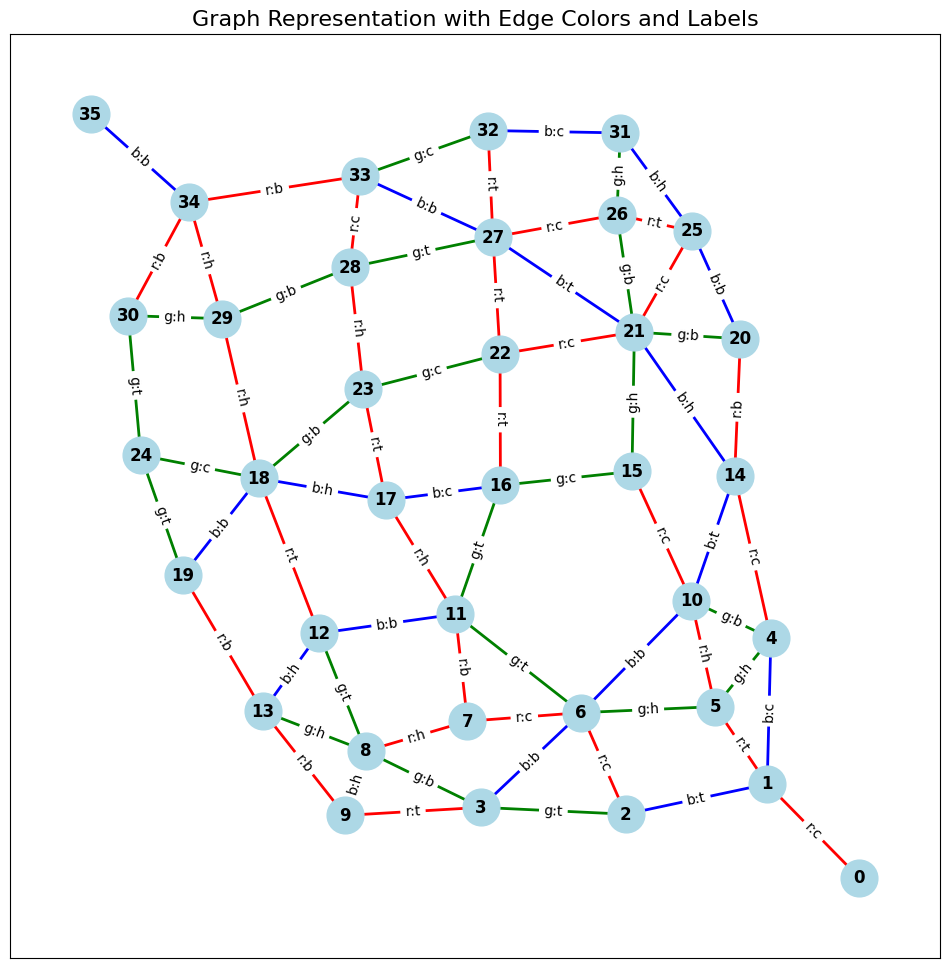

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph_with_colors(connections):
    """
    رسم گراف با یال‌های رنگی و گره‌ها
    :param connections: لیست ارتباطات به صورت (گره 1، گره 2، شرکت، نوع)
    """
    # ایجاد گراف
    G = nx.Graph()

    # اضافه کردن یال‌ها به گراف
    for i, j, company, road_type in connections:
        G.add_edge(i, j, company=company, road_type=road_type)

    # ایجاد موقعیت گره‌ها
    pos = nx.spring_layout(G)

    # رسم گره‌ها
    plt.figure(figsize=(12, 12))
    nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=700)
    nx.draw_networkx_labels(G, pos, font_size=12, font_color="black", font_weight="bold")

    # تنظیم رنگ و نوع یال‌ها
    edge_colors = []
    edge_labels = {}
    for u, v, data in G.edges(data=True):
        # انتخاب رنگ بر اساس شرکت
        color_map = {'r': 'red', 'g': 'green', 'b': 'blue'}
        edge_colors.append(color_map.get(data['company'], 'black'))
        # تنظیم نوع یال
        edge_labels[(u, v)] = f"{data['company']}:{data['road_type']}"

    # رسم یال‌ها
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2)

    # اضافه کردن برچسب‌های یال
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

    # نمایش گراف
    plt.title("Graph Representation with Edge Colors and Labels", fontsize=16)
    plt.show()


# لیست اتصالات نمونه
connections = [
    (0, 1, 'r', 'c'), (1, 2, 'b', 't'), (1, 4, 'b', 'c'), (1, 5, 'r', 't'),
    (2, 3, 'g', 't'), (2, 6, 'r', 'c'), (3, 6, 'b', 'b'), (3, 8, 'g', 'b'),
    (3, 9, 'r', 't'), (4, 5, 'g', 'h'), (4, 10, 'g', 'b'), (4, 14, 'r', 'c'),
    (5, 6, 'g', 'h'), (5, 10, 'r', 'h'), (6, 7, 'r', 'c'), (6, 10, 'b', 'b'),
    (6, 11, 'g', 't'), (7, 8, 'r', 'h'), (7, 11, 'r', 'b'), (8, 9, 'b', 'h'),
    (8, 12, 'g', 't'), (8, 13, 'g', 'h'), (9, 13, 'r', 'b'), (10, 14, 'b', 't'),
    (10, 15, 'r', 'c'), (11, 12, 'b', 'b'), (11, 16, 'g', 't'), (11, 17, 'r', 'h'),
    (12, 13, 'b', 'h'), (12, 18, 'r', 't'), (13, 19, 'r', 'b'), (14, 20, 'r', 'b'),
    (14, 21, 'b', 'h'), (15, 16, 'g', 'c'), (15, 21, 'g', 'h'), (16, 17, 'b', 'c'),
    (16, 22, 'r', 't'), (17, 18, 'b', 'h'), (17, 23, 'r', 't'), (18, 19, 'b', 'b'),
    (18, 23, 'g', 'b'), (18, 24, 'g', 'c'), (18, 29, 'r', 'h'), (19, 24, 'g', 't'),
    (20, 21, 'g', 'b'), (20, 25, 'b', 'b'), (21, 22, 'r', 'c'), (21, 25, 'r', 'c'),
    (21, 26, 'g', 'b'), (21, 27, 'b', 't'), (22, 23, 'g', 'c'), (22, 27, 'r', 't'),
    (23, 28, 'r', 'h'), (24, 30, 'g', 't'), (25, 31, 'b', 'h'), (25, 26, 'r', 't'),
    (26, 27, 'r', 'c'), (26, 31, 'g', 'h'), (27, 28, 'g', 't'), (27, 32, 'r', 't'),
    (27, 33, 'b', 'b'), (28, 29, 'g', 'b'), (28, 33, 'r', 'c'), (29, 30, 'g', 'h'),
    (29, 34, 'r', 'h'), (30, 34, 'r', 'b'), (31, 32, 'b', 'c'), (32, 33, 'g', 'c'),
    (33, 34, 'r', 'b'), (34, 35, 'b', 'b')
]

# رسم گراف
draw_graph_with_colors(connections)
